In [1]:
import os
import json
import cv2
import shutil
import numpy as np
from tqdm import tqdm
from sklearn.cluster import DBSCAN
from ultralytics import YOLO
import os

In [2]:
BASE_PATH = r"D:\AAI_PROJECT\data\provident-vehicle-detection-at-night-pvdn\PVDN\night"

TRAIN_PATH = os.path.join(BASE_PATH, "train")
VAL_PATH = os.path.join(BASE_PATH, "val")

YOLO_PATH = os.path.join(BASE_PATH, "yolo_dataset")

os.makedirs(YOLO_PATH, exist_ok=True)



print("Train exists:", os.path.exists(TRAIN_PATH))
print("Val exists:", os.path.exists(VAL_PATH))

print("Train images:", os.path.exists(os.path.join(TRAIN_PATH, "images")))
print("Val images:", os.path.exists(os.path.join(VAL_PATH, "images")))

print("Annotations train:", os.path.exists(os.path.join(TRAIN_PATH, "labels", "image_annotations.json")))

Train exists: True
Val exists: True
Train images: True
Val images: True
Annotations train: True


In [3]:
for split in ["train", "val"]:
    os.makedirs(os.path.join(YOLO_PATH, "images", split), exist_ok=True)
    os.makedirs(os.path.join(YOLO_PATH, "labels", split), exist_ok=True)

In [4]:
def load_annotations(json_path):
    with open(json_path) as f:
        return json.load(f)

In [5]:
def convert_to_yolo(instances, img_w, img_h, box_size=20):
    labels = []

    for inst in instances:
        x, y = inst["pos"]

        x_center = x / img_w
        y_center = y / img_h
        w = box_size / img_w
        h = box_size / img_h

        labels.append(f"0 {x_center} {y_center} {w} {h}")

    return labels

In [6]:
def process_split(split_path, split_name):
    img_root = os.path.join(split_path, "images")
    ann_path = os.path.join(split_path, "labels", "image_annotations.json")

    data = load_annotations(ann_path)

    for seq in tqdm(os.listdir(img_root)):
        seq_path = os.path.join(img_root, seq)

        for img_name in os.listdir(seq_path):
            img_path = os.path.join(seq_path, img_name)

            if img_name not in data:
                continue

            img = cv2.imread(img_path)
            h, w = img.shape[:2]

            labels = []

            for obj in data[img_name]["annotations"]:
                labels += convert_to_yolo(obj["instances"], w, h)

            # save image
            new_img_name = f"{seq}_{img_name}"
            out_img = os.path.join(YOLO_PATH, "images", split_name, new_img_name)
            shutil.copy(img_path, out_img)

            # save label
            out_label = os.path.join(YOLO_PATH, "labels", split_name, new_img_name.replace(".png", ".txt"))

            with open(out_label, "w") as f:
                f.write("\n".join(labels))

In [8]:
process_split(TRAIN_PATH, "train")
process_split(VAL_PATH, "val")

100%|██████████| 25/25 [00:00<00:00, 2016.18it/s]


In [14]:

# FIXED: Process dataset correctly using keypoint JSON files
def process_split_fixed(split_path, split_name):
    """
    Process PVDN dataset correctly using keypoint JSON files.
    This handles the actual data format (COCO-style annotations + keypoint JSON files).
    """
    import json
    
    img_root = os.path.join(split_path, "images")
    main_ann_path = os.path.join(split_path, "labels", "image_annotations.json")
    keypoints_path = os.path.join(split_path, "labels", "keypoints")
    
    # Load main annotation to get image metadata
    with open(main_ann_path) as f:
        main_data = json.load(f)
    
    # Create a mapping from image_id to image metadata
    image_id_to_meta = {}
    for img_meta in main_data.get("images", []):
        image_id_to_meta[img_meta["id"]] = img_meta
    
    processed_count = 0
    
    # Iterate through all sequence folders
    for seq in tqdm(os.listdir(img_root)):
        seq_path = os.path.join(img_root, seq)
        if not os.path.isdir(seq_path):
            continue
        
        # Iterate through images in the sequence
        for img_name in os.listdir(seq_path):
            img_path = os.path.join(seq_path, img_name)
            if not os.path.isfile(img_path):
                continue
            
            # Try to find the keypoint file for this image
            # The keypoint files are named as numeric IDs (image_id)
            # We need to match the image to an image_id
            
            # First, try to get image info from the image filename
            # Extract the image name without extension
            base_name = os.path.splitext(img_name)[0]
            
            # Look for keypoints file with this base name (as numeric ID)
            try:
                img_id = int(base_name)
                keypoints_file = os.path.join(keypoints_path, f"{img_id}.json")
                
                if not os.path.exists(keypoints_file):
                    continue  # No keypoints for this image, skip
                
                # Read the image to get dimensions
                img = cv2.imread(img_path)
                if img is None:
                    continue
                h, w = img.shape[:2]
                
                # Read keypoint annotations
                with open(keypoints_file) as f:
                    kp_data = json.load(f)
                
                labels = []
                
                # Process annotations (objects/vehicles)
                for obj in kp_data.get("annotations", []):
                    # Get the object position (vehicle center)
                    obj_pos = obj.get("pos")
                    if not obj_pos:
                        continue
                    
                    # Create YOLO label: class center_x center_y width height
                    # For vehicle detection at night, treating each vehicle detection as class 0
                    x_center = obj_pos[0] / w
                    y_center = obj_pos[1] / h
                    
                    # Create a small box around the vehicle (e.g., 20x20 pixels)
                    box_size = 20
                    box_width = box_size / w
                    box_height = box_size / h
                    
                    # Clamp to valid range
                    box_width = min(box_width, 1.0)
                    box_height = min(box_height, 1.0)
                    x_center = max(0.0, min(x_center, 1.0))
                    y_center = max(0.0, min(y_center, 1.0))
                    
                    labels.append(f"0 {x_center} {y_center} {box_width} {box_height}")
                
                # Only save if we have labels
                if labels:
                    # Save image with renamed filename
                    new_img_name = f"{seq}_{img_name}"
                    out_img = os.path.join(YOLO_PATH, "images", split_name, new_img_name)
                    shutil.copy(img_path, out_img)
                    
                    # Save label
                    out_label = os.path.join(YOLO_PATH, "labels", split_name, new_img_name.replace(".png", ".txt"))
                    with open(out_label, "w") as f:
                        f.write("\n".join(labels))
                    
                    processed_count += 1
            
            except (ValueError, json.JSONDecodeError, KeyError):
                # Skip if we can't parse the image ID or keypoint file
                continue
    
    print(f"Processed {processed_count} images for {split_name} split")

# Process both splits
process_split_fixed(TRAIN_PATH, "train")
process_split_fixed(VAL_PATH, "val")


100%|██████████| 145/145 [02:40<00:00,  1.11s/it]


Processed 4690 images for train split


100%|██████████| 25/25 [00:23<00:00,  1.07it/s]

Processed 568 images for val split


In [9]:
yaml_content = f"""
path: {YOLO_PATH}
train: images/train
val: images/val

names:
  0: light
"""

with open(os.path.join(YOLO_PATH, "data.yaml"), "w") as f:
    f.write(yaml_content)

In [10]:
import torch
print(torch.cuda.is_available())

True


In [11]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
GPU name: NVIDIA T1200 Laptop GPU


In [ ]:


# model = YOLO("yolov8n.pt")

# model.train(
#     data=os.path.join(YOLO_PATH, "data.yaml"),
#     epochs=50,
#     imgsz=640,
#     batch=4,        # 🔥 safest for 4GB GPU
#     device=0,
#     workers=2,      # laptop stability
#     cache=False     # avoids RAM overload
# )

      10/50      1.32G      2.191      1.395     0.8618          4        640: 100% ━━━━━━━━━━━━ 1173/1173 2.6it/s 7:26<0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 71/71 9.1it/s 7.8s0.2s
                   all        568        703      0.889      0.634      0.726      0.398

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      11/50      1.34G      2.194      1.387     0.8651          2        640: 100% ━━━━━━━━━━━━ 1173/1173 6.5it/s 3:02<0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 71/71 8.3it/s 8.6s0.1s
                   all        568        703      0.902      0.617      0.735      0.402

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      12/50      1.36G      2.168      1.354     0.8594          4        640: 100% ━━━━━━━━━━━━ 1173/1173 6.5it/s 3:00<0.2s
                 Class     

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000026F825B3310>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

Testing on: S00007/002844.png

image 1/1 D:\AAI_PROJECT\data\provident-vehicle-detection-at-night-pvdn\PVDN\night\test\images\S00007\002844.png: 480x640 1 light, 40.3ms
Speed: 10.0ms preprocess, 40.3ms inference, 26.2ms postprocess per image at shape (1, 3, 480, 640)


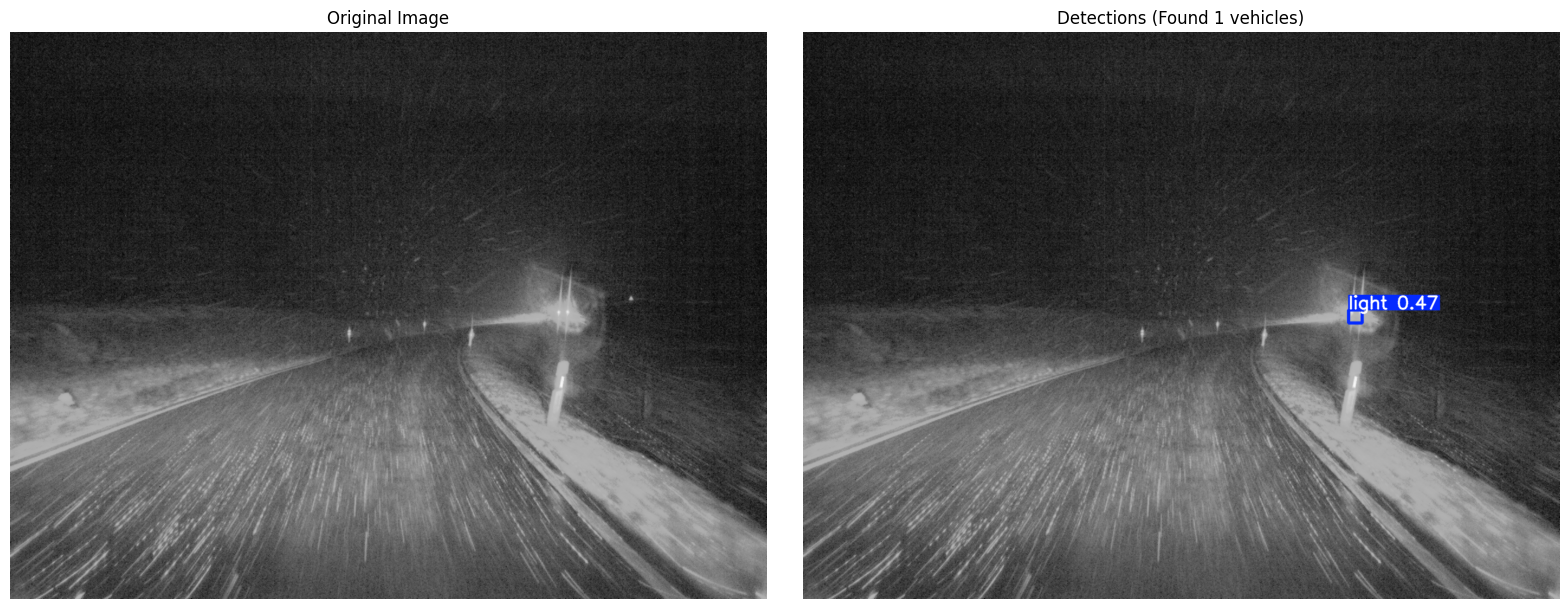


Detections: 1 vehicles found
  Vehicle 1: Box(923, 471, 945, 493), Confidence: 0.469


In [7]:
# Test on a Single Image
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cv2

# Load the trained model (use the latest trained weights)
trained_model = YOLO(os.path.join(YOLO_PATH, "../runs/detect/train3/weights/best.pt"))

# Select a test image
test_img_dir = os.path.join(BASE_PATH, "test/images")
test_sequences = os.listdir(test_img_dir)
test_seq = test_sequences[0]  # Use first sequence
test_seq_path = os.path.join(test_img_dir, test_seq)
test_images = [f for f in os.listdir(test_seq_path) if f.endswith('.png')]

if test_images:
    test_image_name = test_images[132]  # Use first image
    test_image_path = os.path.join(test_seq_path, test_image_name)
    
    print(f"Testing on: {test_seq}/{test_image_name}")
    
    # Run inference
    results = trained_model(test_image_path, conf=0.18)  # conf threshold at 0.3
    
    # Read and display the image with detections
    img = cv2.imread(test_image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Original image
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    
    # Image with detections
    result = results[0]
    img_with_detections = result.plot()  # Returns BGR image with boxes
    img_with_detections_rgb = cv2.cvtColor(img_with_detections, cv2.COLOR_BGR2RGB)
    
    axes[1].imshow(img_with_detections_rgb)
    axes[1].set_title(f"Detections (Found {len(result.boxes)} vehicles)")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    # Print detection details
    print(f"\nDetections: {len(result.boxes)} vehicles found")
    for i, box in enumerate(result.boxes):
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        print(f"  Vehicle {i+1}: Box({x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}), Confidence: {conf:.3f}")
else:
    print(f"No test images found in {test_seq_path}")

In [ ]:
from ultralytics import YOLO
import glob
import os

# Define paths (in case earlier cells haven't run)
BASE_PATH = r"D:\AAI_PROJECT\data\provident-vehicle-detection-at-night-pvdn\PVDN\night"
YOLO_PATH = os.path.join(BASE_PATH, "yolo_dataset")

# Find the best.pt file from the training runs
best_pt_candidates = glob.glob(os.path.join(BASE_PATH, "runs/detect/*/weights/best.pt"))
if best_pt_candidates:
    best_pt_path = best_pt_candidates[-1]  # Use the latest
    print(f"Using model: {best_pt_path}")
else:
    print("Error: No trained model found in runs/detect/*/weights/best.pt")
    print(f"Searched in: {os.path.join(BASE_PATH, 'runs/detect/*/weights/best.pt')}")
    best_pt_path = None

# Use the dynamically created data.yaml
data_yaml_path = os.path.join(YOLO_PATH, "data.yaml")
print(f"Using data.yaml: {data_yaml_path}")

if best_pt_path and os.path.exists(data_yaml_path):
    model = YOLO(best_pt_path)
    
    metrics = model.val(
        data=data_yaml_path,
        split="val",  # Use val split instead of test (test split might not exist)
        conf=0.25,
        iou=0.5,
        plots=True,
        save_json=True
    )
    
    print("=" * 40)
    print("VALIDATION RESULTS")
    print("=" * 40)
    print(f"mAP50     : {metrics.box.map50:.4f}")
    print(f"mAP50-95  : {metrics.box.map:.4f}")
    print(f"Precision : {metrics.box.mp:.4f}")
    print(f"Recall    : {metrics.box.mr:.4f}")
else:
    print("Error: Could not find model or data.yaml")

Using model: D:\AAI_PROJECT\data\provident-vehicle-detection-at-night-pvdn\PVDN\night\runs/detect\train3\weights\best.pt
Using data.yaml: D:\AAI_PROJECT\data\provident-vehicle-detection-at-night-pvdn\PVDN\night\yolo_dataset\data.yaml
Ultralytics 8.3.232  Python-3.11.9 torch-2.7.1+cu118 CUDA:0 (NVIDIA T1200 Laptop GPU, 4096MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.40.3 ms, read: 117.67.8 MB/s, size: 699.3 KB)
val: Scanning D:\AAI_PROJECT\data\provident-vehicle-detection-at-night-pvdn\PVDN\night\yolo_dataset\labels\val.cache... 568 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 568/568 571.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 6.2it/s 5.8s0.1s
                   all        568        703       0.89      0.643      0.792      0.519
Speed: 1.3ms preprocess, 5.2ms inference, 0.0ms loss, 0.8ms postprocess per image
Saving D:\

# Visualization Testing on Test Data

This section runs YOLOv8 on several test images and shows the original frame next to the detected result so you can visually inspect how well the model generalizes to unseen night scenes.

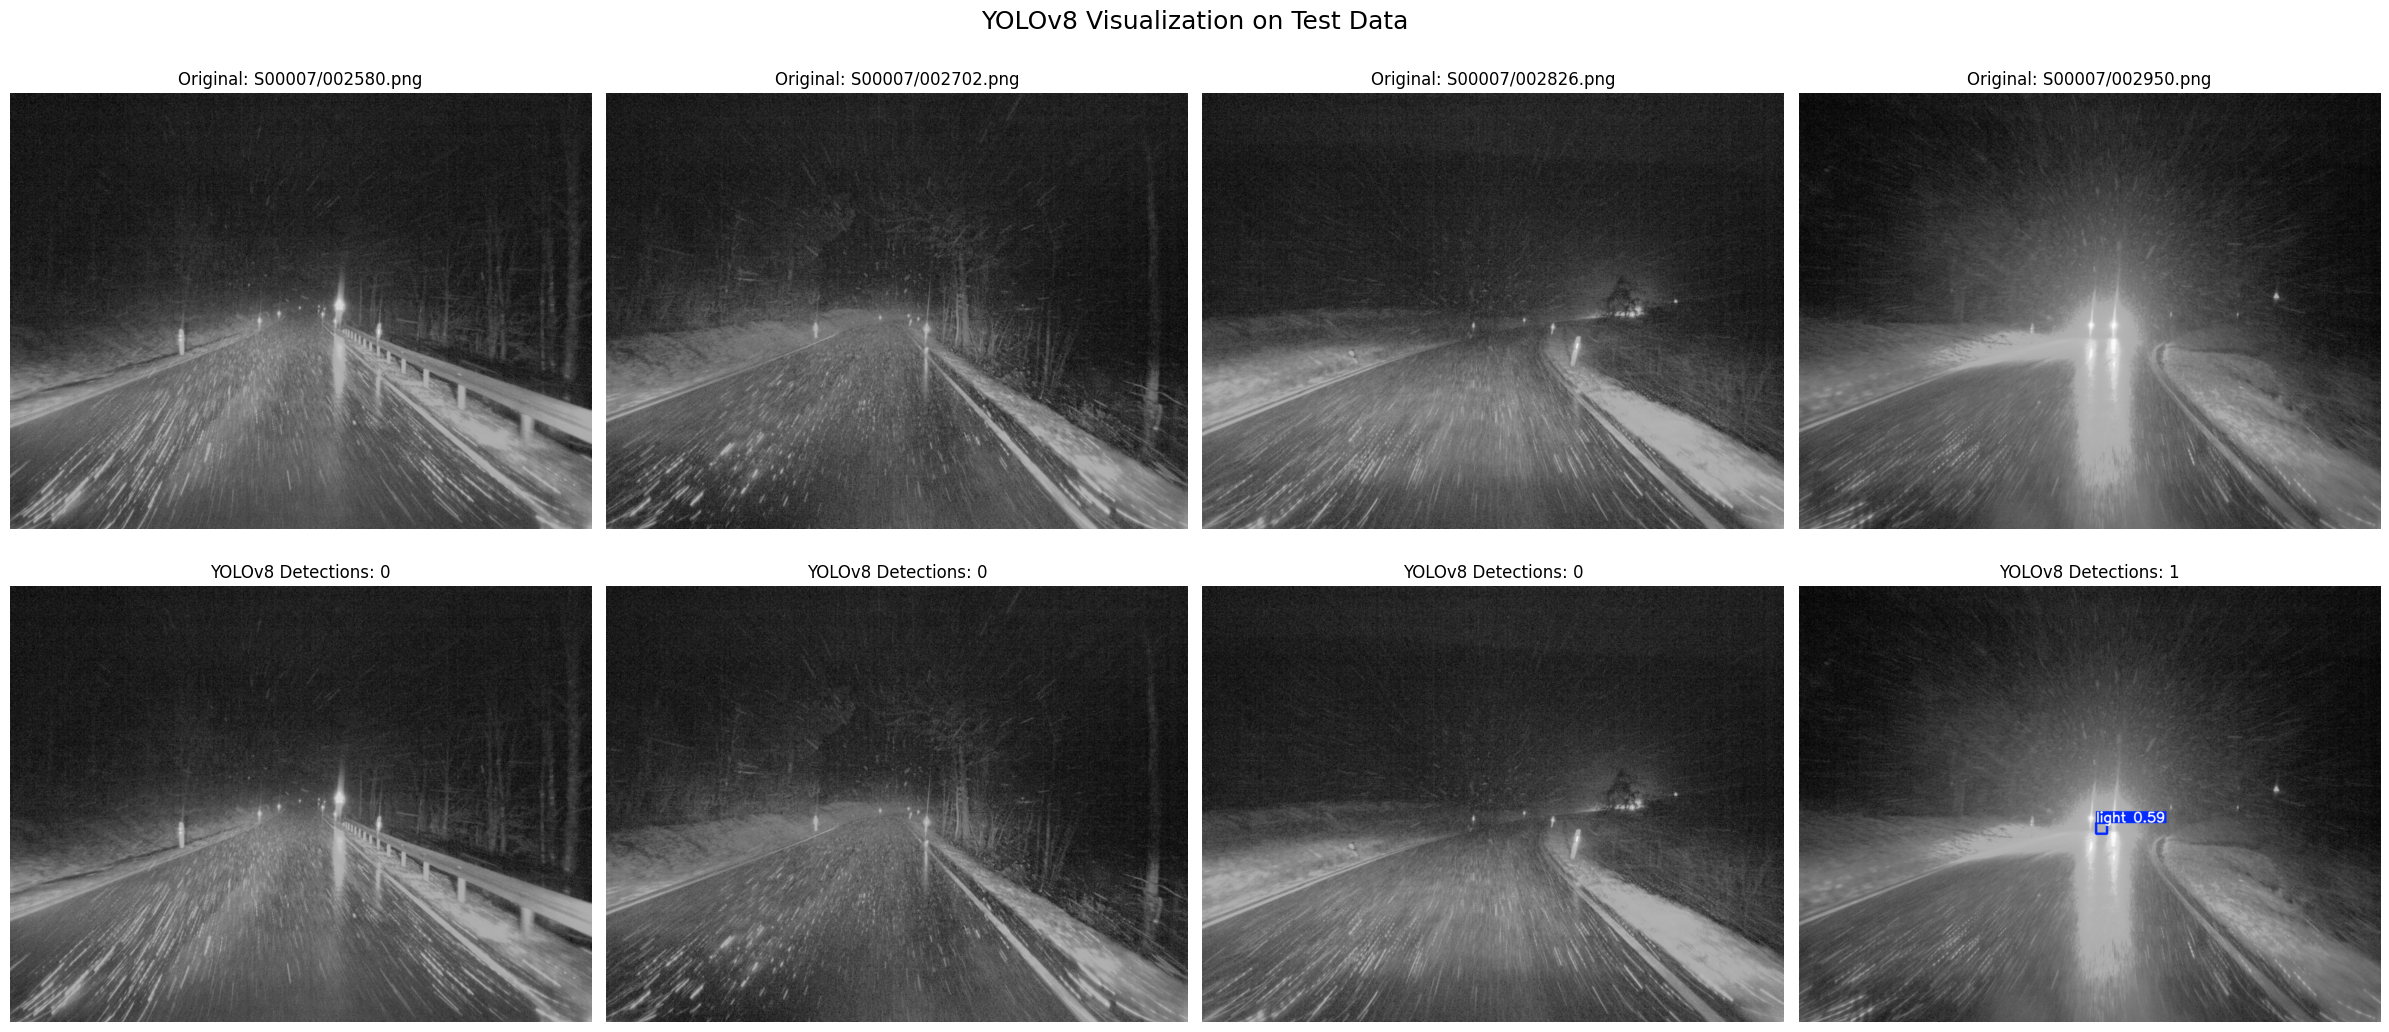

Test visualization completed on sequence S00007 using 4 images.


In [11]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO

# Reuse the already-loaded model if available, otherwise load the latest trained weights.
if 'trained_model' in globals():
    model_for_test_vis = trained_model
else:
    best_candidates = []
    try:
        import glob
        best_candidates = glob.glob(os.path.join(BASE_PATH, "runs/detect/*/weights/best.pt"))
    except Exception:
        best_candidates = []
    if best_candidates:
        model_for_test_vis = YOLO(best_candidates[-1])
    else:
        model_for_test_vis = YOLO(os.path.join(YOLO_PATH, "../runs/detect/train3/weights/best.pt"))

# Collect test images from the test split.
test_img_dir = os.path.join(BASE_PATH, "test", "images")
sequence_dirs = [d for d in os.listdir(test_img_dir) if os.path.isdir(os.path.join(test_img_dir, d))]

if not sequence_dirs:
    print(f"No test sequences found in {test_img_dir}")
else:
    # Pick one sequence and sample a few frames from it for a clean visual comparison.
    test_seq = sorted(sequence_dirs)[0]
    test_seq_path = os.path.join(test_img_dir, test_seq)
    test_images = sorted([f for f in os.listdir(test_seq_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

    if not test_images:
        print(f"No test images found in {test_seq_path}")
    else:
        sample_count = min(4, len(test_images))
        if sample_count == len(test_images):
            sampled_images = test_images
        else:
            indices = np.linspace(0, len(test_images) - 1, sample_count, dtype=int)
            sampled_images = [test_images[i] for i in indices]

        fig, axes = plt.subplots(2, sample_count, figsize=(6 * sample_count, 11))
        if sample_count == 1:
            axes = np.array(axes).reshape(2, 1)

        for col, image_name in enumerate(sampled_images):
            image_path = os.path.join(test_seq_path, image_name)
            image_bgr = cv2.imread(image_path)
            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

            prediction = model_for_test_vis(image_path, conf=0.18, verbose=False)[0]
            prediction_bgr = prediction.plot()
            prediction_rgb = cv2.cvtColor(prediction_bgr, cv2.COLOR_BGR2RGB)

            axes[0, col].imshow(image_rgb)
            axes[0, col].set_title(f"Original: {test_seq}/{image_name}")
            axes[0, col].axis("off")

            axes[1, col].imshow(prediction_rgb)
            axes[1, col].set_title(f"YOLOv8 Detections: {len(prediction.boxes)}")
            axes[1, col].axis("off")

        plt.suptitle("YOLOv8 Visualization on Test Data", fontsize=18, y=0.98)
        plt.tight_layout()
        plt.show()

        print(f"Test visualization completed on sequence {test_seq} using {sample_count} images.")

# YOLOv8 vs. Blob Tracking on Test Data

This section compares the raw YOLOv8 detections with the blob-tracking pipeline on the same consecutive test frames. The blob-tracking view shows how detections are linked across time instead of treating each frame independently.

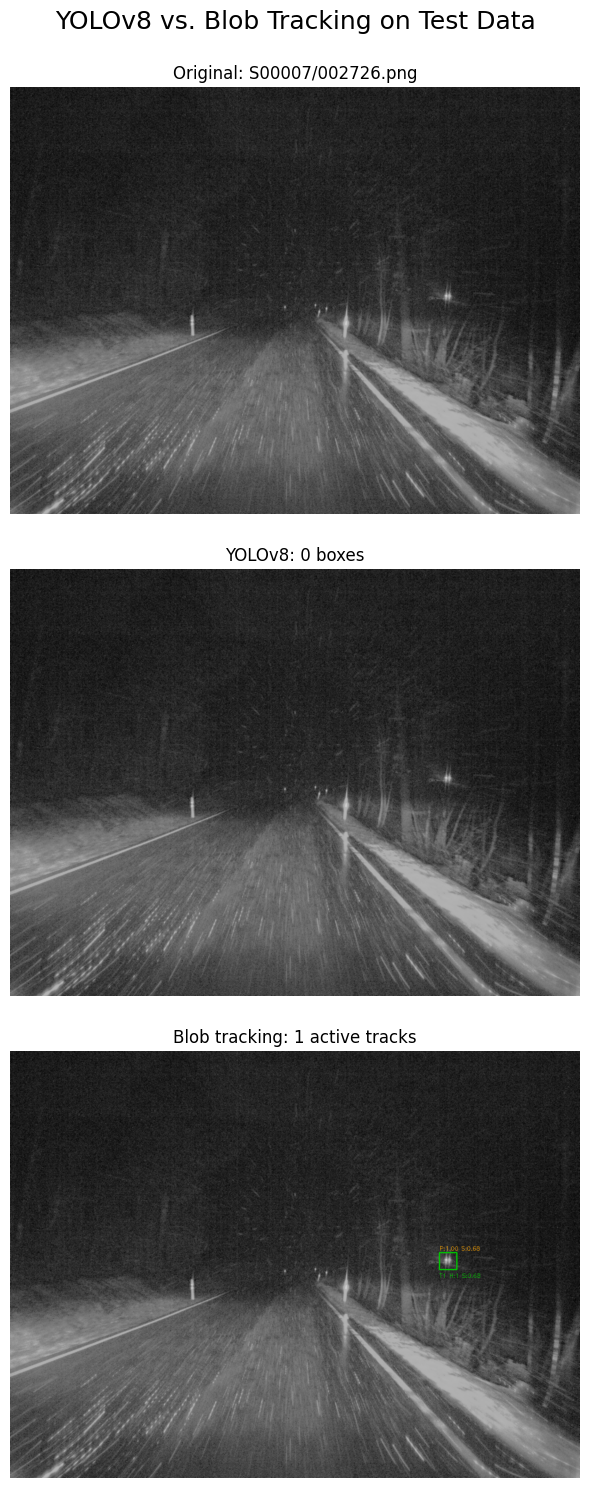

Blob-tracking comparison completed on sequence S00007 using 1 consecutive frames.


In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import torch
from ultralytics import YOLO

# Reuse backend helpers from the real blob-tracking pipeline.
backend_dir = Path(BASE_PATH).parent / "GUI" / "nightlight-vision" / "backend"
if str(backend_dir) not in sys.path:
    sys.path.insert(0, str(backend_dir))

import run_detection as rd

# Load the patch model used by the blob-tracking pipeline.
patch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
patch_model_path = rd.resolve_model_path()
patch_model = rd.load_model(patch_model_path, patch_device)

# Reuse the YOLO model if it exists.
if 'model_for_test_vis' in globals():
    yolo_model = model_for_test_vis
elif 'trained_model' in globals():
    yolo_model = trained_model
else:
    yolo_candidates = []
    try:
        import glob
        yolo_candidates = glob.glob(os.path.join(BASE_PATH, "runs/detect/*/weights/best.pt"))
    except Exception:
        yolo_candidates = []
    if yolo_candidates:
        yolo_model = YOLO(yolo_candidates[-1])
    else:
        yolo_model = YOLO(os.path.join(YOLO_PATH, "../runs/detect/train3/weights/best.pt"))

# Gather a short consecutive test clip from the first test sequence.
test_img_dir = os.path.join(BASE_PATH, "test", "images")
sequence_dirs = [d for d in os.listdir(test_img_dir) if os.path.isdir(os.path.join(test_img_dir, d))]

if not sequence_dirs:
    print(f"No test sequences found in {test_img_dir}")
else:
    test_seq = sorted(sequence_dirs)[0]
    test_seq_path = os.path.join(test_img_dir, test_seq)
    test_images = sorted([f for f in os.listdir(test_seq_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))])

    if not test_images:
        print(f"No test images found in {test_seq_path}")
    else:
        sample_count = min(1, len(test_images))
        start_index = max(0, (len(test_images) // 2) - 20)
        sampled_images = test_images[start_index:start_index + sample_count]
        if len(sampled_images) < sample_count:
            sampled_images = test_images[:sample_count]

        tracker = rd.ReflectionTracker()
        fig, axes = plt.subplots(3, len(sampled_images), figsize=(6 * len(sampled_images), 15))
        if len(sampled_images) == 1:
            axes = np.array(axes).reshape(3, 1)

        for col, image_name in enumerate(sampled_images):
            image_path = os.path.join(test_seq_path, image_name)
            image_bgr = cv2.imread(image_path)
            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

            # YOLOv8 view.
            yolo_result = yolo_model(image_path, conf=0.18, verbose=False)[0]
            yolo_bgr = yolo_result.plot()
            yolo_rgb = cv2.cvtColor(yolo_bgr, cv2.COLOR_BGR2RGB)

            # Blob-tracking view from the real backend pipeline.
            proposals, detections, max_prob, max_score, mean_top3_score = rd.analyze_frame_blob(
                image_bgr, patch_model, patch_device
            )
            tracks = tracker.update(detections)

            blob_vis = image_bgr.copy()
            for det in detections:
                x1, y1, x2, y2 = det["box"]
                cv2.rectangle(blob_vis, (x1, y1), (x2, y2), (0, 165, 255), 2)
                cv2.putText(
                    blob_vis,
                    f"P:{det['prob']:.2f} S:{det['score']:.2f}",
                    (x1, max(y1 - 5, 18)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.42,
                    (0, 165, 255),
                    1,
                )

            for track in tracks:
                if track.missed_frames > 0:
                    continue
                x1, y1, x2, y2 = track.last_box()
                is_warning_track = track.is_warning_track()
                color = (0, 0, 255) if is_warning_track else (0, 200, 0)
                thickness = 3 if is_warning_track else 2
                cv2.rectangle(blob_vis, (x1, y1), (x2, y2), color, thickness)
                cv2.putText(
                    blob_vis,
                    f"T{track.track_id} H:{track.hits} S:{track.avg_score():.2f}",
                    (x1, min(y2 + 18, blob_vis.shape[0] - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.42,
                    color,
                    1,
                )
                centers = list(track.centers)
                for idx in range(1, len(centers)):
                    cv2.line(blob_vis, centers[idx - 1], centers[idx], color, 2)

            blob_rgb = cv2.cvtColor(blob_vis, cv2.COLOR_BGR2RGB)

            axes[0, col].imshow(image_rgb)
            axes[0, col].set_title(f"Original: {test_seq}/{image_name}")
            axes[0, col].axis("off")

            axes[1, col].imshow(yolo_rgb)
            axes[1, col].set_title(f"YOLOv8: {len(yolo_result.boxes)} boxes")
            axes[1, col].axis("off")

            axes[2, col].imshow(blob_rgb)
            axes[2, col].set_title(f"Blob tracking: {len(tracks)} active tracks")
            axes[2, col].axis("off")

        plt.suptitle("YOLOv8 vs. Blob Tracking on Test Data", fontsize=18, y=0.995)
        plt.tight_layout()
        plt.show()

        print(f"Blob-tracking comparison completed on sequence {test_seq} using {len(sampled_images)} consecutive frames.")
